# Rocketpy - Carcará Rocket Design



# Execução de Bibliotecas:


Importação de bibliotecas do Rocketpy:

In [1]:
!pip install --upgrade rocketpy
!matplotlib.patches
!pip install geopandas
!pip install rocketpy
!curl -o NACA0012-radians.txt https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/airfoils/NACA0012-radians.txt
!curl -o AT_ClasseM2019.eng https://raw.githubusercontent.com/andrefcmoraes/CRD/refs/heads/main/Prop/AT_ClasseM2019.eng
!curl -o powerOffDragCurve.csv https://raw.githubusercontent.com/andrefcmoraes/CRD/refs/heads/main/Propuls%C3%A3o/powerOffDragCurve.csv
!curl -o powerOnDragCurve.csv https://raw.githubusercontent.com/andrefcmoraes/CRD/refs/heads/main/Propuls%C3%A3o/powerOnDragCurve.csv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.5/372.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.5 MB/s eta 0:00:00
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65860 sha256=c7230e8de17a1853a3c8b7c9c91e71a5bde9512ac4c17a0769b565b0cf191260
  Stored in directory: /root/.cache/pip/wheels/83/ee/f2/65cecfd948f1429ead035fd6d56bc6bd6574a636ddc4d65cbd
Successfully built simplekml
/bin/bash: line 1: matplotlib.patches: command not found
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1052  100  1052    0     0   6637      0 --:--:-- --:--:-- --:--:--  6658
  % Total    % Received % Xferd  Average Speed   Time    T

# Simulação atmosférica em tempo real:

Importação dos dados atmosféricos, tipo de motor, foquete e voo:

In [2]:
from rocketpy import Environment, SolidMotor, Rocket, Flight

Extrair dados Atmosféricos:

In [3]:
help(Environment)

Help on class Environment in module rocketpy.environment.environment:

class Environment(builtins.object)
 |  Environment(gravity=None, date=None, latitude=0.0, longitude=0.0, elevation=0.0, datum='SIRGAS2000', timezone='UTC', max_expected_height=80000.0)
 |
 |  Keeps all environment information stored, such as wind and temperature
 |  conditions, as well as gravity.
 |
 |  Attributes
 |  ----------
 |  Environment.earth_radius : float
 |      Value of Earth's Radius as 6.3781e6 m.
 |  Environment.air_gas_constant : float
 |      Value of Air's Gas Constant as 287.05287 J/K/Kg
 |  Environment.gravity : Function
 |      Gravitational acceleration. Positive values point the
 |      acceleration down. See :meth:`Environment.set_gravity_model` for more
 |      information.
 |  Environment.latitude : float
 |      Launch site latitude.
 |  Environment.longitude : float
 |      Launch site longitude.
 |  Environment.datum : string
 |      The desired reference ellipsoid model, the following 

Criação de gráficos com matplotlib que serão exibidos posteriormente:

In [4]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

Aqui serão armazenados dados relacionados ao clima e ao condições de vento do local de lançamento:

In [5]:
from datetime import datetime

env = Environment(
    latitude= -21.90795,
    longitude= -48.96156,
    elevation= 495,     # elevação
    date=(2025, 9, 11, 16)  # Tomorrow's date in year, month, day, hour UTC format
)

 As condições meteorológicas são importadas de organizações meteorológicas, como NOAA e ECMWF. Aqui será feito a importação de dados de acordo com o dia do local:

In [6]:
import datetime

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  # Hour given in UTC time

Agora definimos o modelo atmosférico a ser usado:

In [7]:
env.set_atmospheric_model(type="Forecast", file="GFS")

Podemos ver como será o tempo naquele lugar:


Gravity Details

Acceleration of gravity at surface level:    9.7861 m/s²
Acceleration of gravity at  79.233 km (ASL): 9.5474 m/s²


Launch Site Details

Launch Date: 2025-09-11 12:00:00 UTC
Launch Site Latitude: -21.90795°
Launch Site Longitude: -48.96156°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 90584.06 W    7572074.74 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 471.5 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 79.233 km
Forecast Time Period: from 2025-09-10 06:00:00 to 2025-09-26 06:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From -90.0° to 90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 3.89 m/s
Surface Wind Direction: 110.17°
Surface Wind Heading: 290.17°
Surface Pressure: 965.26 hPa
Surface Temperature: 297.29 K
Surface Air Density: 1.131 kg/m³
Surface Speed of Sound: 345.65 m/s


Earth Model Details

Earth Radius at Launch s

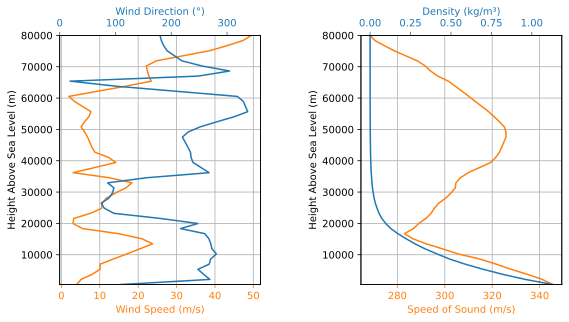

In [8]:
env.info()

# Definição do Motor:

Parâmetos do motor:

**OBS:** Só podem ser aceitos arquivos .eng e .csv de uma medição de teste estático.

In [9]:
H3000 = SolidMotor(
    thrust_source="AT_ClasseM2019.eng",
    dry_mass=4.5,
    dry_inertia=(0.7, 0.7, 0.1),
    nozzle_radius= 34.5 / 1000,
    grain_number=5,
    grain_density=1800,
    grain_outer_radius=47 / 1000,
    grain_initial_inner_radius= 10 / 1000,
    grain_initial_height=100 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=415.29/1000,
    center_of_dry_mass_position=0.3169,
    nozzle_position=0,
    burn_time=3.137,
    throat_radius=20 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

/usr/local/lib/python3.12/dist-packages/rocketpy/motors/motor.py:990: UserWarning: burn_time argument (0, 3.137) is out of thrust source time range. Using thrust_source boundary times instead: (0, 2.28) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


Curva de empuxo:

Nozzle Details
Nozzle Radius: 0.0345 m
Nozzle Throat Radius: 0.02 m

Grain Details
Number of Grains: 5
Grain Spacing: 0.005 m
Grain Density: 1800 kg/m3
Grain Outer Radius: 0.047 m
Grain Inner Radius: 0.01 m
Grain Height: 0.1 m
Grain Volume: 0.001 m3
Grain Mass: 1.193 kg

Motor Details
Total Burning Time: 3.137 s
Total Propellant Mass: 5.963 kg
Structural Mass Ratio: 0.430
Average Propellant Exhaust Velocity: 1467.900 m/s
Average Thrust: 2790.301 N
Maximum Thrust: 4307.411 N at 1.2 s after ignition.
Total Impulse: 8753.174 Ns



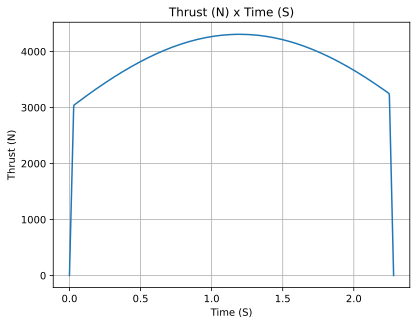

In [10]:
H3000.info()

# Definição de Foguete:

In [11]:
DDD = Rocket(
    radius=154 / 2000,
    mass=16.717,
    inertia=(6.349, 6.349, 0.053),
    power_off_drag="powerOffDragCurve.csv",
    power_on_drag="powerOnDragCurve.csv",
    center_of_mass_without_motor=1.09,
    coordinate_system_orientation="tail_to_nose",
)

rail_buttons = DDD.set_rail_buttons(
    upper_button_position=0.2,
    lower_button_position=-0.9,
    angular_position=83,
)

In [12]:
DDD.info()


Inertia Details

Rocket Mass: 16.717 kg (without motor)
Rocket Dry Mass: 16.717 kg (with unloaded motor)
Rocket Loaded Mass: 16.717 kg
Rocket Structural Mass Ratio: 1.000
Rocket Inertia (with unloaded motor) 11: 6.349 kg*m2
Rocket Inertia (with unloaded motor) 22: 6.349 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.053 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.077 m
Rocket Frontal Area: 0.018627 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.090 m
Rocket Center of Dry Mass - Center of Propellant Mass: 1.090 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.000 m


Aerodynamics Lift Coefficient Derivatives


Center of Pressure


Stability

Center of Mass position (time=0): 1.090 m
Center of Pressure position (time=0): 0.000

Informar a posição, em metros, da área de saída do bico do motor em relação ao sistema de coordenadas previamente definido:

In [13]:
DDD.add_motor(H3000, position=-1.300)

Resultados do Cálculo de trilhos:

In [14]:
rail_buttons.info()

Geometric information of the RailButtons:
-----------------------------------------
Distance from one button to the other: 1.100 m
Angular position of the buttons: 83.000 deg



Adicionar elementos aerodinâmicos do foguete: Nariz, quatro barbatanas e uma cauda

In [15]:
nose_cone = DDD.add_nose(length=0.40, kind="ogive", position=1.002)

fin_set = DDD.add_trapezoidal_fins(
    n=4,
    root_chord=0.26,
    tip_chord=0.15,
    span=0.124,
    position=-1.0,
    cant_angle=0.4468,
    airfoil=("NACA0012-radians.txt", "radians"),
)

#tail = DDD.add_tail(
    #top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
#)

Para verificar todas as informações do foguete:


Inertia Details

Rocket Mass: 16.717 kg (without motor)
Rocket Dry Mass: 21.217 kg (with unloaded motor)
Rocket Loaded Mass: 27.180 kg
Rocket Structural Mass Ratio: 0.781
Rocket Inertia (with unloaded motor) 11: 22.287 kg*m2
Rocket Inertia (with unloaded motor) 22: 22.287 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.153 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.077 m
Rocket Frontal Area: 0.018627 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.440 m
Rocket Center of Dry Mass - Nozzle Exit: 1.950 m
Rocket Center of Dry Mass - Center of Propellant Mass: 1.535 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.337 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 6.527/rad

Center of Pressure

No

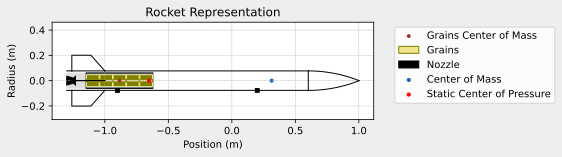


Mass Plots
----------------------------------------


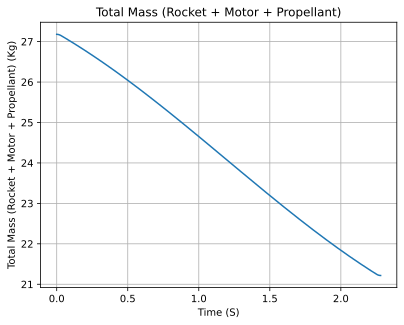

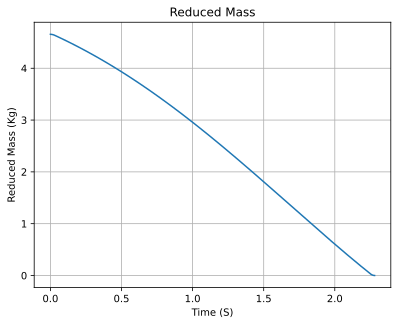


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


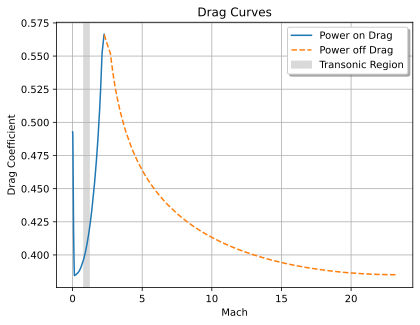


Stability Plots
--------------------


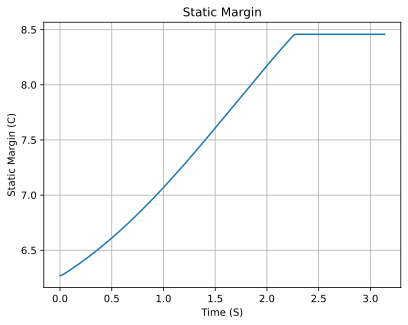

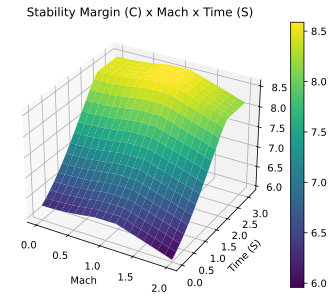


Thrust-to-Weight Plot
----------------------------------------


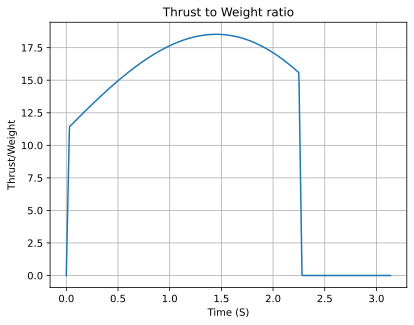

In [16]:
DDD.all_info()

Parâ-quedas:

**OBS:** Este codigo deve ser executado somente uma vez! Caso contrario, será adcionado vários parâ-quedas de acordo com a quantidade de execução.

In [18]:
Main = DDD.add_parachute(
    "Main",
    cd_s=4.7124,
    trigger="apogee",
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

#Drogue = DDD.add_parachute(
  #  "Drogue",
 #   cd_s=1.17801,
#    trigger="apogee",
#    sampling_rate=105,
  #  lag=1.5,
 #   noise=(0, 8.3, 0.5),
#)

Resultados parâ-quedas:

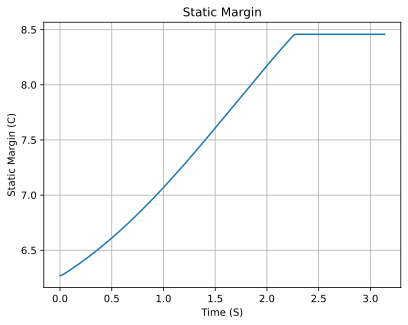

In [19]:
DDD.plots.static_margin()

Simulação de Voo:

Inserir dados:

In [20]:
test_flight = Flight(
    rocket=DDD, environment=env, rail_length=6, inclination=85, heading=0
)

 Estado do foguete no momento da ignição:

In [21]:
test_flight.prints.initial_conditions()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 471.48 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.748 | e1: -0.033 | e2: 0.029 | e3: 0.662
Euler Angles - Spin φ : 83.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 6.271 c


Condições do vento à superfície no local de lançamento:

In [22]:
test_flight.prints.surface_wind_conditions()


Surface Wind Conditions

Frontal Surface Wind Speed: 1.32 m/s
Lateral Surface Wind Speed: 3.66 m/s


Condições do trilho de lançamento:

In [23]:
test_flight.prints.launch_rail_conditions()


Launch Rail

Launch Rail Length: 6 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Voo livre:

In [24]:
test_flight.prints.out_of_rail_conditions()


Rail Departure State

Rail Departure Time: 0.304 s
Rail Departure Velocity: 32.318 m/s
Rail Departure Stability Margin: 6.462 c
Rail Departure Angle of Attack: 6.927°
Rail Departure Thrust-Weight Ratio: 13.562
Rail Departure Reynolds Number: 3.082e+05


 Podemos verificar no tempo de queima, que é o momento em que o motor para de queimar. Deste ponto em diante, o foguete voará sem nenhum empuxo:

In [25]:
test_flight.prints.burn_out_conditions()


Burn out State

Burn out time: 3.137 s
Altitude at burn out: 1099.062 m (ASL) | 627.584 m (AGL)
Rocket speed at burn out: 302.312 m/s
Freestream velocity at burn out: 302.819 m/s
Mach Number at burn out: 0.878
Kinetic energy at burn out: 9.695e+05 J


Apogeu:

*   Acima do nível do mar ASL
*   Acima do nível do solo AGL



In [26]:
test_flight.prints.apogee_conditions()


Apogee State

Apogee Time: 23.411 s
Apogee Altitude: 3521.004 m (ASL) | 3049.526 m (AGL)
Apogee Freestream Speed: 12.921 m/s
Apogee X position: 303.737 m
Apogee Y position: 382.602 m
Apogee latitude: -21.9045114°
Apogee longitude: -48.9586178°


Ejeção de parâ-quedas:

In [27]:
test_flight.prints.events_registered()


Parachute Events

Parachute: Main
	Ejection time: 23.419 s
	Inflation time: 24.919 s
	Freestream speed at inflation: 19.279 m/s
	Altitude at inflation: 3510.171 m (ASL) | 3038.693 m (AGL)


Impacto:

In [28]:
test_flight.prints.impact_conditions()


Impact Conditions

Time of impact: 343.902 s
X impact: 971.332 m
Y impact: 404.401 m
Altitude impact: 471.478 m (ASL) | -0.000 m (AGL) 
Latitude: -21.9043153°
Longitude: -48.9521511°
Vertical velocity at impact: -8.835 m/s
Number of parachutes triggered until impact: 1


Resumo do máximo de valores registrados durante o voo para vários parâmetros:

In [29]:
test_flight.prints.maximum_values()


Maximum Values

Maximum Speed: 326.830 m/s at 2.27 s
Maximum Mach Number: 0.952 Mach at 2.27 s
Maximum Reynolds Number: 3.041e+06 at 2.27 s
Maximum Dynamic Pressure: 5.871e+04 Pa at 2.27 s
Maximum Acceleration During Motor Burn: 165.316 m/s² at 1.32 s
Maximum Gs During Motor Burn: 16.858 g at 1.32 s
Maximum Acceleration After Motor Burn: -0.000 m/s² at 0.00 s
Maximum Gs After Motor Burn: -0.000 Gs at 0.00 s
Maximum Stability Margin: 8.584 c at 2.28 s
Maximum Upper Rail Button Normal Force: 1.410 N
Maximum Upper Rail Button Shear Force: 0.141 N
Maximum Lower Rail Button Normal Force: 9.942 N
Maximum Lower Rail Button Shear Force: 1.002 N


Resultados Gerais:

In [30]:
test_flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 471.48 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.748 | e1: -0.033 | e2: 0.029 | e3: 0.662
Euler Angles - Spin φ : 83.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 6.271 c


Surface Wind Conditions

Frontal Surface Wind Speed: 1.32 m/s
Lateral Surface Wind Speed: 3.66 m/s


Launch Rail

Launch Rail Length: 6 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.304 s
Rail Departure Velocity: 32.318 m/s
Rail Departure Stability Margin: 6.462 c
Rail Departure Angle of Attack: 6.927°
Rail Departure Thrust-Weight Ratio: 13.562
Rail Departure Reynolds Number: 3.082e+05


Burn out State

Burn out time: 3.137 s
Altitude at burn out: 1099.062 m (ASL) | 627.584 m (AGL)
Rocket speed at burn out: 302.312 m/s
Freestream velocity

# Trajetória de Voo:

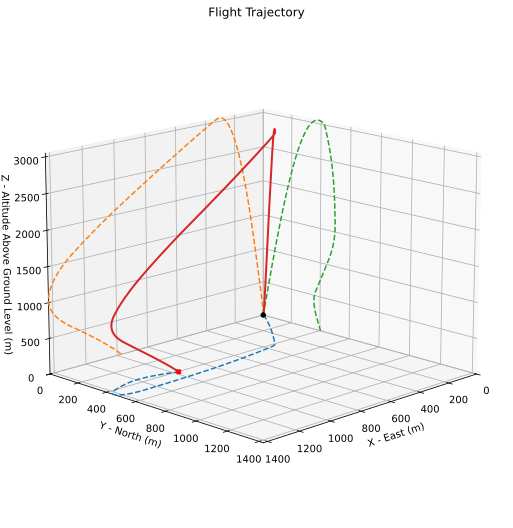

In [31]:
test_flight.plots.trajectory_3d()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 471.48 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.748 | e1: -0.033 | e2: 0.029 | e3: 0.662
Euler Angles - Spin φ : 83.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 6.271 c


Surface Wind Conditions

Frontal Surface Wind Speed: 1.32 m/s
Lateral Surface Wind Speed: 3.66 m/s


Launch Rail

Launch Rail Length: 6 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.304 s
Rail Departure Velocity: 32.318 m/s
Rail Departure Stability Margin: 6.462 c
Rail Departure Angle of Attack: 6.927°
Rail Departure Thrust-Weight Ratio: 13.562
Rail Departure Reynolds Number: 3.082e+05


Burn out State

Burn out time: 3.137 s
Altitude at burn out: 1099.062 m (ASL) | 627.584 m (AGL)
Rocket speed at burn out: 302.312 m/s
Freestream velocity

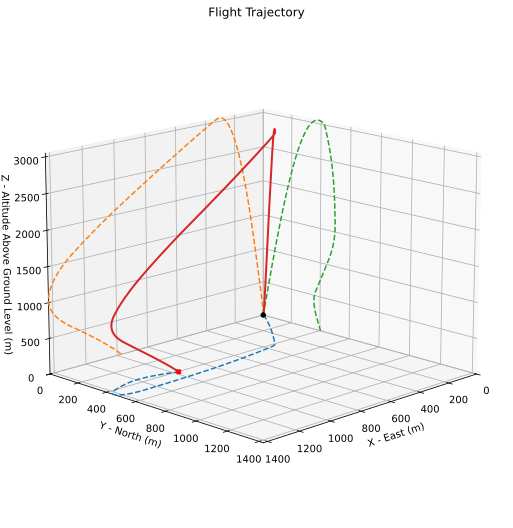



Trajectory Kinematic Plots



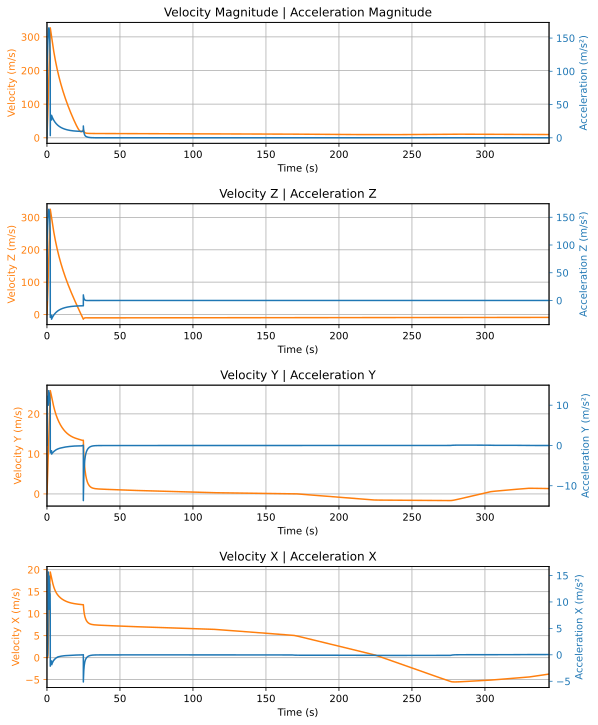



Angular Position Plots



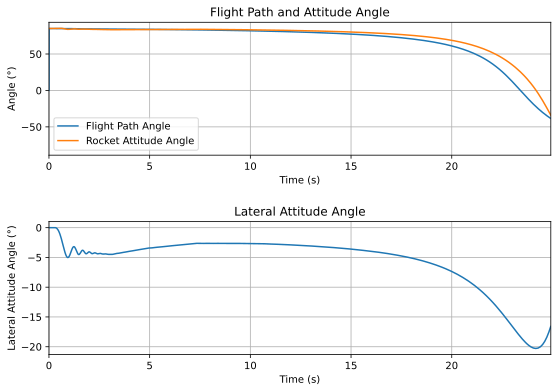



Path, Attitude and Lateral Attitude Angle plots



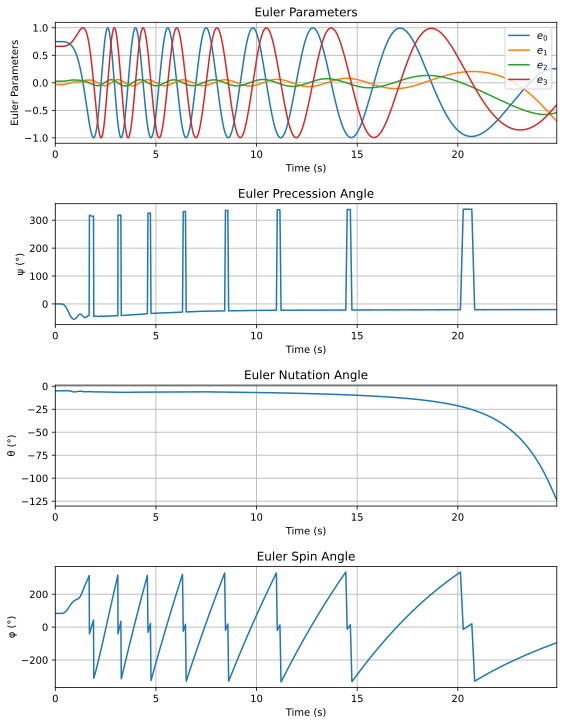



Trajectory Angular Velocity and Acceleration Plots



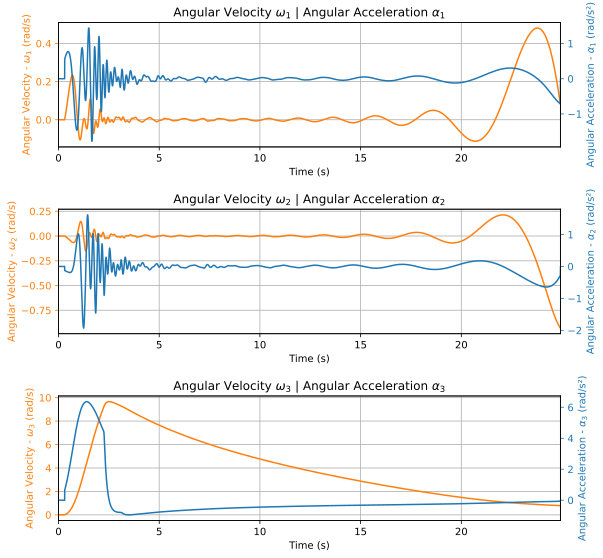



Aerodynamic Forces Plots



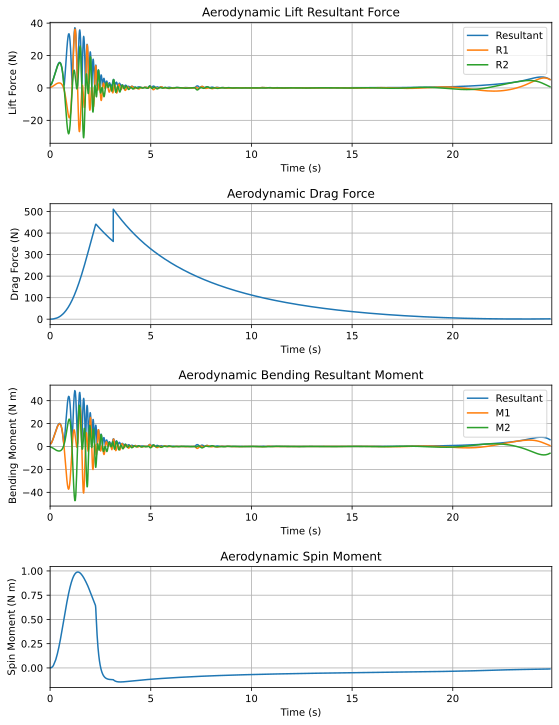



Rail Buttons Forces Plots



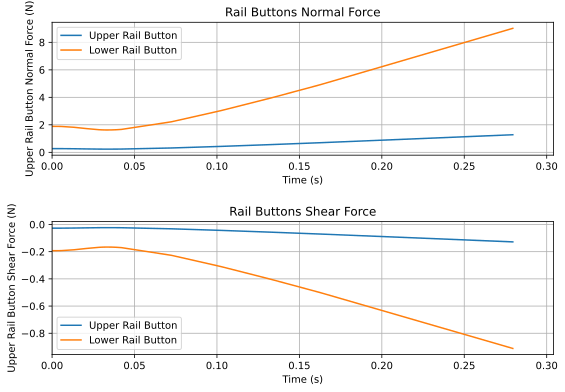



Trajectory Energy Plots



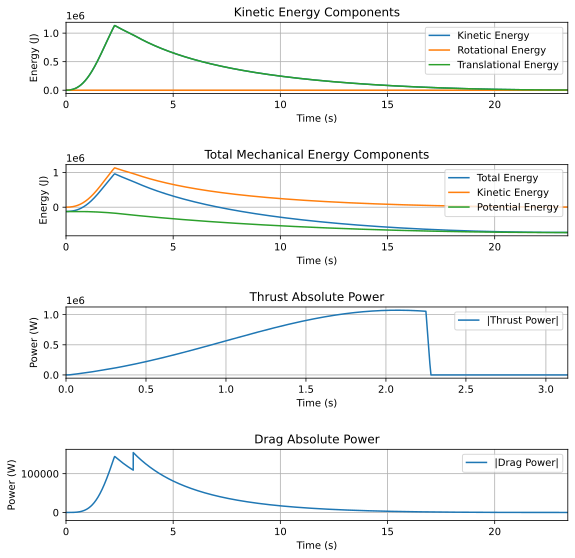



Trajectory Fluid Mechanics Plots



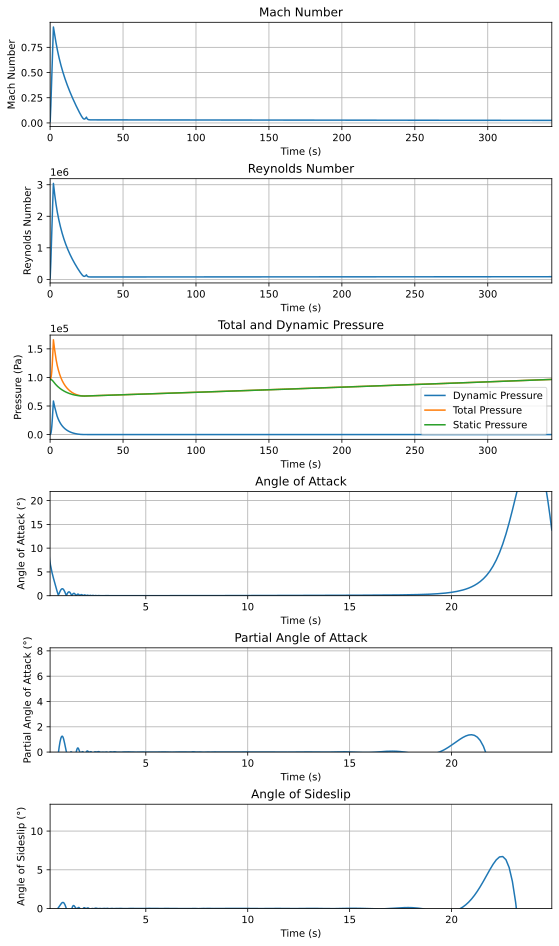



Trajectory Stability and Control Plots



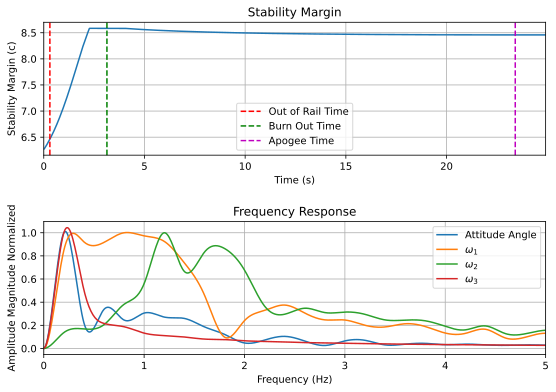



Rocket and Parachute Pressure Plots



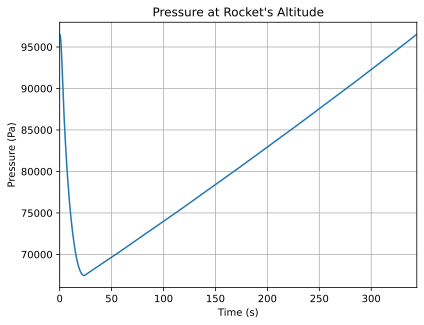


Parachute:  Main


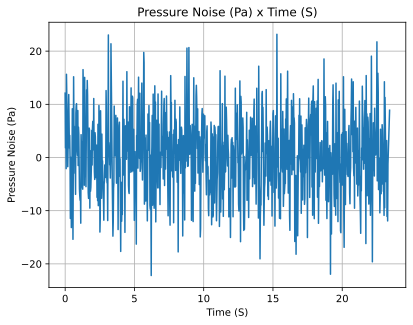

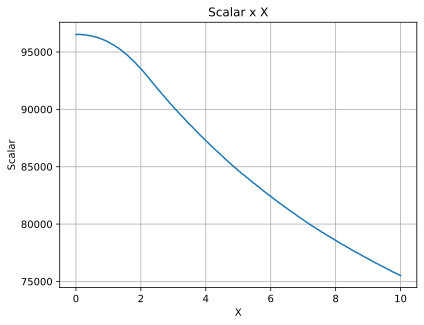

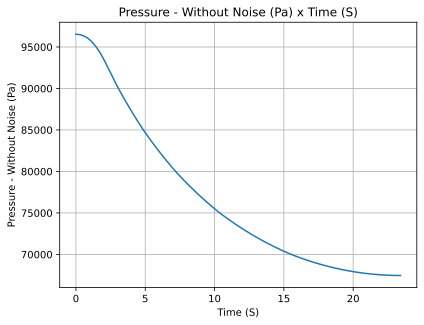

In [32]:
test_flight.all_info()

# Gogle Earth:

In [ ]:
test_flight.export_kml(
    file_name="trajectory.kml",
    extrude=True,
    altitude_mode="relative_to_ground",
)

# Algumas analises:

Apogeu em função da massa:

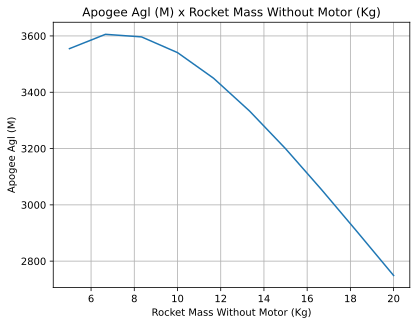

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Apogee AGL (m))'

In [33]:
from rocketpy.utilities import apogee_by_mass

apogee_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=10, plot=True)

Velocidade fora do trilho em função da massa:

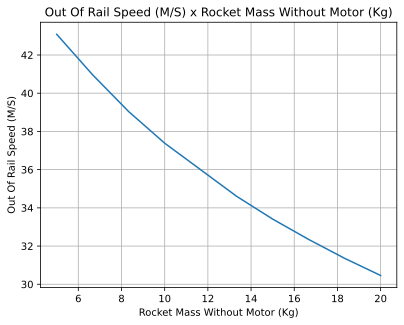

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Out of Rail Speed (m/s))'

In [34]:
from rocketpy.utilities import liftoff_speed_by_mass

liftoff_speed_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=10, plot=True)

Estabilidade Aerodinâmica:

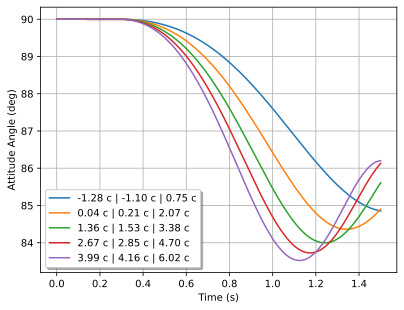

In [35]:
# Helper class
from rocketpy import Function
import copy

# Prepare a copy of the rocket
DDD2 = copy.deepcopy(DDD)

# Prepare Environment Class
custom_env = Environment()
custom_env.set_atmospheric_model(type="custom_atmosphere", wind_v=-5)

# Simulate Different Static Margins by Varying Fin Position
simulation_results = []

for factor in [-0.5, -0.2, 0.1, 0.4, 0.7]:
    # Modify rocket fin set by removing previous one and adding new one
    DDD2.aerodynamic_surfaces.pop(-1)

    fin_set = DDD2.add_trapezoidal_fins(
        n=4,
        root_chord=0.120,
        tip_chord=0.040,
        span=0.100,
        position=-1.04956 * factor,
    )
    # Simulate
    test_flight = Flight(
        rocket=DDD2,
        environment=custom_env,
        rail_length=5.2,
        inclination=90,
        heading=0,
        max_time_step=0.01,
        max_time=5,
        terminate_on_apogee=True,
        verbose=False,
    )
    # Store Results
    static_margin_at_ignition = DDD2.static_margin(0)
    static_margin_at_out_of_rail = DDD2.static_margin(test_flight.out_of_rail_time)
    static_margin_at_steady_state = DDD2.static_margin(test_flight.t_final)
    simulation_results += [
        (
            test_flight.attitude_angle,
            "{:1.2f} c | {:1.2f} c | {:1.2f} c".format(
                static_margin_at_ignition,
                static_margin_at_out_of_rail,
                static_margin_at_steady_state,
            ),
        )
    ]

Function.compare_plots(
    simulation_results,
    lower=0,
    upper=1.5,
    xlabel="Time (s)",
    ylabel="Attitude Angle (deg)",
)